# CNN with BatchNorm, GAP, Augmentation, and Weighted Loss

- Replaces the large flatten-based classifier with global average pooling
- Uses stronger training augmentation
- Trains longer with early stopping on validation F2

**Objective**
Test whether a smaller classifier head plus stronger augmentation improves generalization and reduces the early plateau seen in the previous weighted BatchNorm CNN experiment.


In [1]:
import sys
import os
import copy

sys.path.append(os.path.abspath("../.."))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
)

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.cnn_batchnorm_gap import BatchNormGAPCNN
from src.training.trainer import train_one_epoch, validate_one_epoch


In [2]:
use_mps = True

print("MPS available:", torch.backends.mps.is_available())
device = torch.device("mps" if (use_mps and torch.backends.mps.is_available()) else "cpu")
print(f"Using device: {device}")


MPS available: True
Using device: mps


In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../../data/splits/train.csv",
    val_csv="../../data/splits/val.csv",
    test_csv="../../data/splits/test.csv",
    image_dir="../../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=224),
)

train_df = pd.read_csv("../../data/splits/train.csv")

num_melanoma = (train_df["label"] == 0).sum()
num_nevus = (train_df["label"] == 1).sum()

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print("pos_weight:", pos_weight)


pos_weight: tensor([6.0244], device='mps:0')


In [4]:
model = BatchNormGAPCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

model_save_path = os.path.abspath("../../models/cnn_batchnorm_gap_augmented_weighted.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

num_epochs = 50
early_stopping_patience = 8

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f2s = []
val_f2s = []
learning_rates = []

best_val_f2 = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_model_state = None


In [5]:
for epoch in range(num_epochs):
    current_lr = optimizer.param_groups[0]["lr"]

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_metrics["f2"])

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])
    train_f2s.append(train_metrics["f2"])
    val_f2s.append(val_metrics["f2"])
    learning_rates.append(current_lr)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics["f2"] > best_val_f2:
        best_val_f2 = val_metrics["f2"]
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, model_save_path)
        print(f"Saved best model at epoch {best_epoch}")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print(f"Best validation F2: {best_val_f2:.4f} at epoch {best_epoch}")

if best_model_state is not None:
    model.load_state_dict(best_model_state)


Epoch [1/50] | LR: 0.001000 | Train Loss: 1.0239, Train Acc: 0.5669, Train F2: 0.5305 | Val Loss: 0.8695, Val Acc: 0.6360, Val F2: 0.6199
Saved best model at epoch 1


Epoch [2/50] | LR: 0.001000 | Train Loss: 0.9390, Train Acc: 0.6129, Train F2: 0.5681 | Val Loss: 0.9495, Val Acc: 0.6471, Val F2: 0.5858


Epoch [3/50] | LR: 0.001000 | Train Loss: 0.9388, Train Acc: 0.6404, Train F2: 0.5873 | Val Loss: 0.9031, Val Acc: 0.7229, Val F2: 0.6124


Epoch [4/50] | LR: 0.001000 | Train Loss: 0.8955, Train Acc: 0.6541, Train F2: 0.5898 | Val Loss: 0.8640, Val Acc: 0.6053, Val F2: 0.6142


Epoch [5/50] | LR: 0.001000 | Train Loss: 0.8560, Train Acc: 0.6849, Train F2: 0.6105 | Val Loss: 0.7899, Val Acc: 0.6590, Val F2: 0.6400
Saved best model at epoch 5


...

Epoch [21/50] | LR: 0.000500 | Train Loss: 0.7431, Train Acc: 0.7502, Train F2: 0.6627 | Val Loss: 0.7480, Val Acc: 0.6863, Val F2: 0.6605


Epoch [22/50] | LR: 0.000250 | Train Loss: 0.7244, Train Acc: 0.7399, Train F2: 0.6569 | Val Loss: 0.7352, Val Acc: 0.7468, Val F2: 0.6731


Epoch [23/50] | LR: 0.000250 | Train Loss: 0.7146, Train Acc: 0.7568, Train F2: 0.6586 | Val Loss: 0.7319, Val Acc: 0.7374, Val F2: 0.6828


Epoch [24/50] | LR: 0.000250 | Train Loss: 0.7149, Train Acc: 0.7496, Train F2: 0.6623 | Val Loss: 0.7504, Val Acc: 0.7545, Val F2: 0.6854


Epoch [25/50] | LR: 0.000250 | Train Loss: 0.7075, Train Acc: 0.7644, Train F2: 0.6731 | Val Loss: 0.7258, Val Acc: 0.7587, Val F2: 0.6852
Early stopping triggered at epoch 25
Best validation F2: 0.6892 at epoch 17


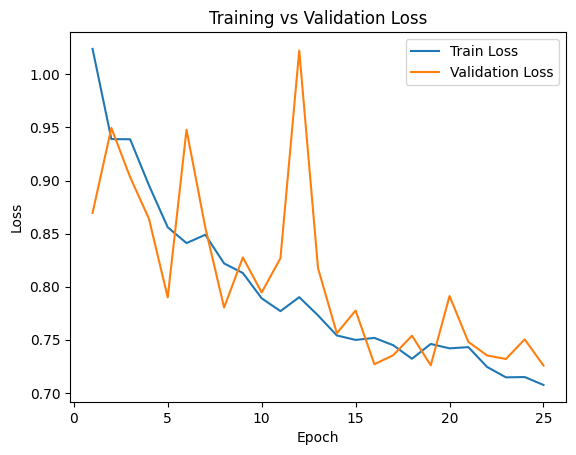

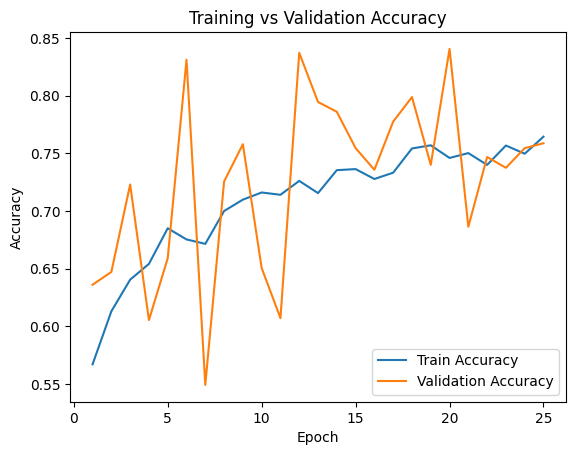

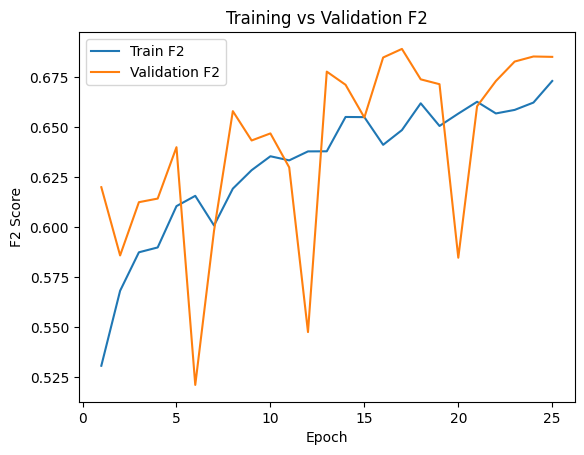

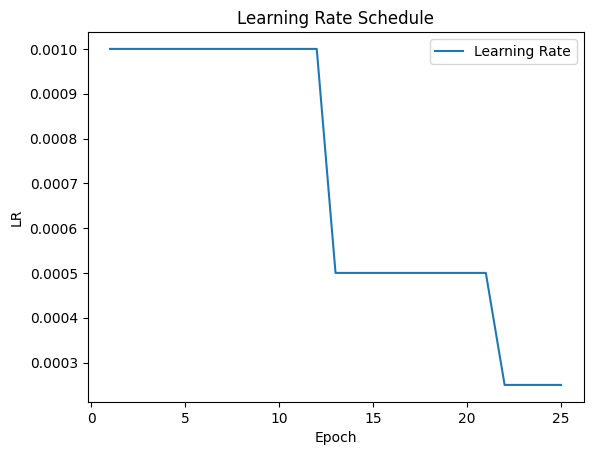

In [6]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_f2s, label="Train F2")
plt.plot(epochs, val_f2s, label="Validation F2")
plt.xlabel("Epoch")
plt.ylabel("F2 Score")
plt.title("Training vs Validation F2")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, learning_rates, label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()
plt.show()


This section sweeps thresholds on the validation set and keeps the threshold with the best F2 score.


In [9]:
model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)
best_threshold = 0.5
best_f2 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f2 = fbeta_score(val_labels, preds, beta=2)

    print(
        f"Threshold={threshold:.2f} | "
        f"F2={f2:.4f} | "
        f"Precision={precision_score(val_labels, preds, zero_division=0):.4f} | "
        f"Recall={recall_score(val_labels, preds, zero_division=0):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f2 > best_f2:
        best_f2 = f2
        best_threshold = threshold

print(f"Best threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F2=0.6221 | Precision=0.2539 | Recall=0.9760 | Balanced Acc=0.7500
Threshold=0.10 | F2=0.6236 | Precision=0.2567 | Recall=0.9701 | Balanced Acc=0.7519
Threshold=0.15 | F2=0.6245 | Precision=0.2610 | Recall=0.9581 | Balanced Acc=0.7539
Threshold=0.20 | F2=0.6289 | Precision=0.2649 | Recall=0.9581 | Balanced Acc=0.7584
Threshold=0.25 | F2=0.6334 | Precision=0.2689 | Recall=0.9581 | Balanced Acc=0.7628
Threshold=0.30 | F2=0.6396 | Precision=0.2765 | Recall=0.9521 | Balanced Acc=0.7693
Threshold=0.35 | F2=0.6524 | Precision=0.2910 | Recall=0.9461 | Balanced Acc=0.7817
Threshold=0.40 | F2=0.6701 | Precision=0.3145 | Recall=0.9341 | Balanced Acc=0.7981
Threshold=0.45 | F2=0.6853 | Precision=0.3447 | Recall=0.9102 | Balanced Acc=0.8115
Threshold=0.50 | F2=0.6892 | Precision=0.3776 | Recall=0.8683 | Balanced Acc=0.8153
Threshold=0.55 | F2=0.6868 | Precision=0.4041 | Recall=0.8323 | Balanced Acc=0.8143
Threshold=0.60 | F2=0.6432 | Precision=0.4189 | Recall=0.7425 | Balanced Acc

Confusion Matrix:
[[758 248]
 [ 29 138]]

              precision    recall  f1-score   support

           0     0.9632    0.7535    0.8455      1006
           1     0.3575    0.8263    0.4991       167

    accuracy                         0.7639      1173
   macro avg     0.6603    0.7899    0.6723      1173
weighted avg     0.8769    0.7639    0.7962      1173



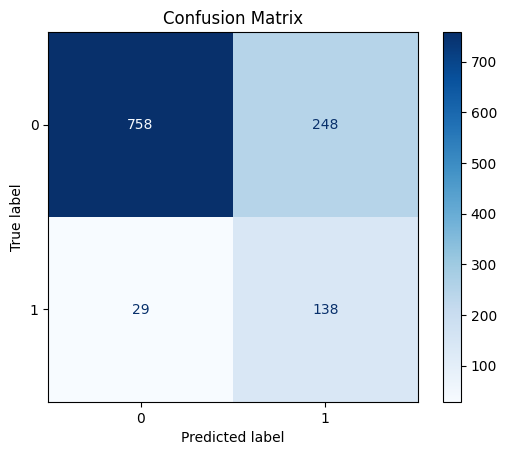

In [11]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
        for images, labels in test_loader:
                images = images.to(device)
                outputs = model(images)
                probs = torch.sigmoid(outputs).squeeze(1)
                preds = (probs >= threshold).long()

                all_labels.extend(labels.numpy())
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4, zero_division=0))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


## Remarks

05.cnn_batchnorm_gap_augmented_weighted.ipynb is a meaningful improvement overall, especially if your main goal is better-balanced melanoma detection rather than just maximizing recall.

Compared with 03.cnn_batchnorm_weighted.ipynb, the new run is better on the metrics that matter most here:

- Best validation F2 improved from about 0.6892 vs the old run’s threshold-swept validation F2 around 0.6699.
- Test accuracy improved from about 0.7178 to 0.7639.
- Positive-class precision improved from about 0.3263 to 0.3575.
- Positive-class recall dropped from about 0.9222 to 0.8263.

So the short verdict is: better overall, with a more balanced precision/recall tradeoff, but slightly worse recall than before. If you care most about not missing melanoma at all costs, the old run was more aggressive. If you care about a stronger overall classifier with fewer false alarms, this new one is better.

What the notebook is doing:

- It loads the train/val/test splits and the HAM10000 images.
- It applies stronger training augmentation but keeps validation/test transforms clean.
- It computes pos_weight for BCEWithLogitsLoss so melanoma gets more weight during training because the classes are imbalanced.
- It trains a new compact CNN, BatchNormGAPCNN, from cnn_batchnorm_gap.py.
- It tracks train/val loss, accuracy, and F2 every epoch.
- It uses ReduceLROnPlateau to lower the learning rate when validation F2 stops improving.
- It uses early stopping so training stops once validation F2 has plateaued for long enough.
- After training, it sweeps classification thresholds on the validation set and picks the threshold with the best F2.
- It evaluates on the test set with that best threshold and prints the confusion matrix and classification report.

Why those steps were added:

- Global average pooling:
In the old CNN, the flatten layer fed a huge fully connected head. The new model shrinks that dramatically, which reduces over-parameterization and usually improves generalization. Your new model is about 110k parameters instead of about 25.8M.
- Stronger augmentation:
This helps the model avoid memorizing superficial image patterns and learn more robust lesion features.
- Weighted BCE loss:
The dataset is imbalanced, so without weighting the model would lean too hard toward the majority class.
- LR scheduler:
This was useful here. The model improved again after the LR dropped from 0.001 to 0.0005 around epoch 13, which is a good sign that the scheduler helped it move past the early plateau.
- Early stopping:
It stopped at epoch 25 with best validation F2 at epoch 17. That means continuing longer at this setup was no longer buying much.
- Threshold sweep:
For imbalanced binary classification, 0.5 is not always best. In this run, 0.50 happened to be the best threshold on validation, which is a nice sign the outputs are better calibrated than before.

What the training curve says:

- The model learned steadily rather than getting stuck immediately.
- Validation was still noisy, but much less “stuck at one level” than before.
- The best phase was after the first LR reduction.
- Train and validation F2 stay reasonably close, so this still does not look like severe overfitting.